# Data Collection

In [30]:
import subprocess

In [31]:
def pipeline(file, n, r):
    cmd = [
        "java", "-jar", "negsel2.jar", 
        "-self", "english.train", 
        "-n", str(n), 
        "-r", str(r), 
        "-c", "-l"
    ]
    with open(file, 'r') as f:
        result = subprocess.run(cmd, stdin=f, capture_output=True, text=True)
    return [float(line) for line in result.stdout.splitlines() if line.strip()]

In [33]:
results = {}
n = 10

for r in range(1, 10):
    print(f"Processing r={r}")
    english = pipeline("english.test", n, r)
    tagalog = pipeline("tagalog.test", n, r)
    y_true = [0] * len(english) + [1] * len(tagalog)
    y_scores = english + tagalog
    results[r] = {"y_true": y_true, "y_scores": y_scores}

Processing r=1
Processing r=2
Processing r=3
Processing r=4
Processing r=5
Processing r=6
Processing r=7
Processing r=8
Processing r=9


# Evaluation

In [38]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

r=1 | AUC: 0.5435
r=2 | AUC: 0.7396
r=3 | AUC: 0.8311
r=4 | AUC: 0.7916
r=5 | AUC: 0.7282
r=6 | AUC: 0.6681
r=7 | AUC: 0.5907
r=8 | AUC: 0.5202
r=9 | AUC: 0.5121


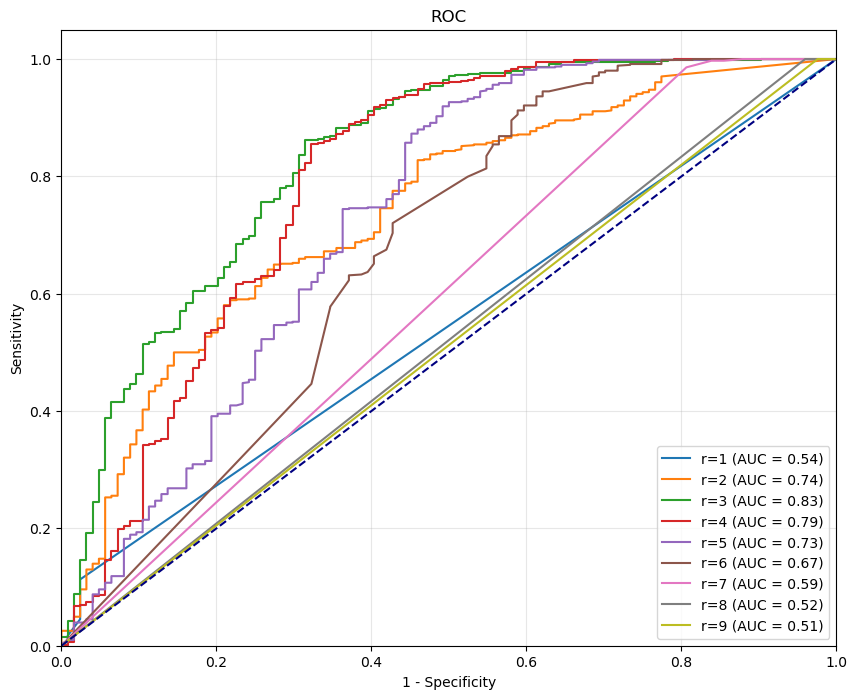

In [35]:
plt.figure(figsize=(10, 8))

for r, data in results.items():
    x, y, _ = roc_curve(data["y_true"], data["y_scores"])
    auc_score = auc(x, y)
    print(f"r={r} | AUC: {auc_score:.4f}")
    plt.plot(x, y, label=f'r={r} (AUC = {auc_score:.2f})')

plt.plot([0, 1], [0, 1], color='navy', linestyle='--') 
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1 - Specificity')
plt.ylabel('Sensitivity')
plt.title('ROC')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

#### 1.1 

In Figure 1 we can see $(a)$ $r=1$, $(b)$ $r=7$ and $(c)$ $r=4$

#### 1.2

As $r$ acts as a threshold for the number of matching contiguous characters, it is hard to distinguish between english and tagalog for $r=1$ and $r=9$ because the detectors become either too general or too specific.

The best performance is achieved for $r=3$

#### 1.3

We use $r=3$ from previous task.

In [36]:
other_languages = ["hiligaynon.txt", "middle-english.txt", "plautdietsch.txt", "xhosa.txt"]
others = {}
n = 10
r = 3 

for language in other_languages:
    print(f"Comparing english vs {language.split(".")[0]}")
    english = pipeline("english.test", n, r)
    other = pipeline(f"./lang/{language}", n, r)
    y_true = [0] * len(english) + [1] * len(other)
    y_scores = english + other
    others[language] = {"y_true": y_true, "y_scores": y_scores}

Comparing english vs hiligaynon
Comparing english vs middle-english
Comparing english vs plautdietsch
Comparing english vs xhosa


hiligaynon
    AUC: 0.8397
middle-english
    AUC: 0.5424
plautdietsch
    AUC: 0.7747
xhosa
    AUC: 0.8893


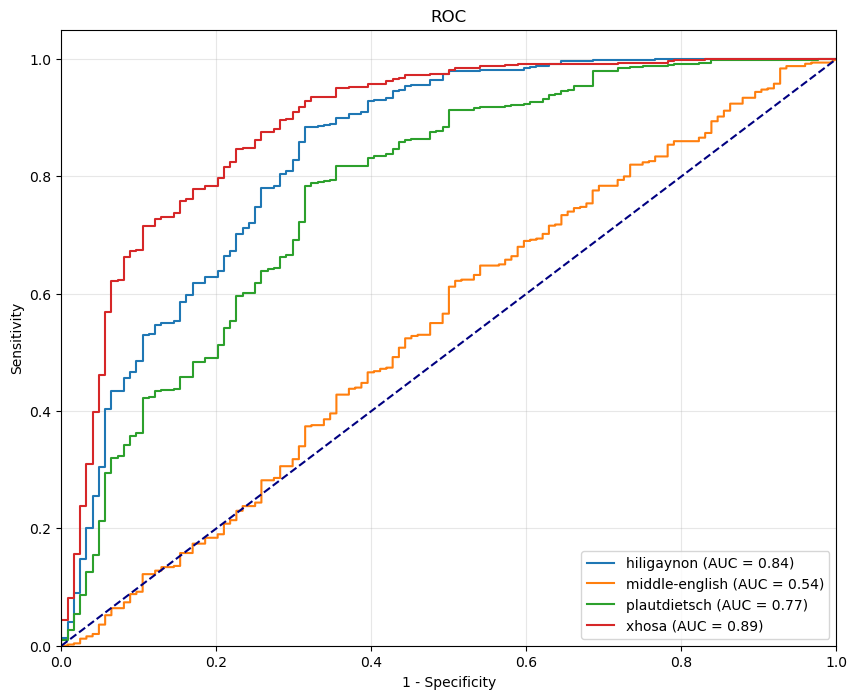

In [39]:
plt.figure(figsize=(10, 8))

for language, data in others.items():
    x, y, _ = roc_curve(data["y_true"], data["y_scores"])
    auc_score = auc(x, y)
    print(f"{language.split(".")[0]}\n    AUC: {auc_score:.4f}")
    plt.plot(x, y, label=f'{language.split(".")[0]} (AUC = {auc_score:.2f})')

plt.plot([0, 1], [0, 1], color='navy', linestyle='--') 
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1 - Specificity')
plt.ylabel('Sensitivity')
plt.title('ROC')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

The language xhosa $(\text{AUC} = 0.89)$ can be discriminated the best, whereas middle-english $(\text{AUC} = 0.54)$ can't be distinguished well. This difficulty arises because middle-english shares many common contiguous substrings with english.

#### 1.4

If $n<r$, then it is impossible to satisfy the matching.

If $n\gg r$, then the detectors become too general because a very short matching sequence is likely to occur by chance within a long pattern. This leads to a high false-positive rate.